In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('data/Physical_Activity_Monitoring_unlabeled.csv')
print("Колонки:", df.columns.tolist())
print("\nПервые 5 строк:")
print(df.head())
print("\nФорма:", df.shape)

Колонки: ['timestamp', 'handTemperature', 'handAcc16_1', 'handAcc16_2', 'handAcc16_3', 'handAcc6_1', 'handAcc6_2', 'handAcc6_3', 'handGyro1', 'handGyro2', 'handGyro3', 'handMagne1', 'handMagne2', 'handMagne3', 'handOrientation1', 'handOrientation2', 'handOrientation3', 'handOrientation4', 'chestTemperature', 'chestAcc16_1', 'chestAcc16_2', 'chestAcc16_3', 'chestAcc6_1', 'chestAcc6_2', 'chestAcc6_3', 'chestGyro1', 'chestGyro2', 'chestGyro3', 'chestMagne1', 'chestMagne2', 'chestMagne3', 'chestOrientation1', 'chestOrientation2', 'chestOrientation3', 'chestOrientation4', 'ankleTemperature', 'ankleAcc16_1', 'ankleAcc16_2', 'ankleAcc16_3', 'ankleAcc6_1', 'ankleAcc6_2', 'ankleAcc6_3', 'ankleGyro1', 'ankleGyro2', 'ankleGyro3', 'ankleMagne1', 'ankleMagne2', 'ankleMagne3', 'ankleOrientation1', 'ankleOrientation2', 'ankleOrientation3', 'ankleOrientation4', 'subject_id']

Первые 5 строк:
   timestamp  handTemperature  handAcc16_1  handAcc16_2  handAcc16_3  \
0     252.75          34.8750     0.902

In [3]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 534601 entries, 0 to 534600
Data columns (total 53 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          534601 non-null  float64
 1   handTemperature    530560 non-null  float64
 2   handAcc16_1        530560 non-null  float64
 3   handAcc16_2        530560 non-null  float64
 4   handAcc16_3        530560 non-null  float64
 5   handAcc6_1         530560 non-null  float64
 6   handAcc6_2         530560 non-null  float64
 7   handAcc6_3         530560 non-null  float64
 8   handGyro1          530560 non-null  float64
 9   handGyro2          530560 non-null  float64
 10  handGyro3          530560 non-null  float64
 11  handMagne1         530560 non-null  float64
 12  handMagne2         530560 non-null  float64
 13  handMagne3         530560 non-null  float64
 14  handOrientation1   530560 non-null  float64
 15  handOrientation2   530560 non-null  float64
 16  handOrientati

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,...,-0.025606,0.030239,-14.5447,27.3336,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,...,-0.670163,1.786200,-32.8257,-15.7719,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,...,-0.009741,-0.006579,-18.8171,16.3089,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,...,-0.163470,-3.495570,-26.7418,34.3566,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,...,-0.028172,-0.003737,-17.7798,-3.9981,10.99500,0.171133,-0.748343,0.252988,-0.588807,6


In [4]:

missing = df.isnull().sum().sort_values(ascending=False)
print("Количество пропусков по столбцам")
print(missing[missing > 0])

print("\nПроцент пропусков")
print((missing / len(df)) * 100)

feature_cols = [col for col in df.columns if col not in ['timestamp', 'subject_id']]
print("\nСтатистика признаков (describe)")
df[feature_cols].describe()

Количество пропусков по столбцам
handTemperature      4041
handAcc16_2          4041
handAcc16_1          4041
handAcc16_3          4041
handAcc6_1           4041
handMagne3           4041
handAcc6_2           4041
handAcc6_3           4041
handGyro1            4041
handGyro2            4041
handGyro3            4041
handMagne1           4041
handMagne2           4041
handOrientation4     4041
handOrientation1     4041
handOrientation2     4041
handOrientation3     4041
ankleOrientation2    2546
ankleOrientation3    2546
ankleTemperature     2546
ankleAcc16_1         2546
ankleOrientation4    2546
ankleGyro2           2546
ankleGyro1           2546
ankleAcc6_3          2546
ankleOrientation1    2546
ankleMagne3          2546
ankleMagne2          2546
ankleMagne1          2546
ankleGyro3           2546
ankleAcc6_1          2546
ankleAcc16_3         2546
ankleAcc16_2         2546
ankleAcc6_2          2546
chestAcc16_2          809
chestTemperature      809
chestAcc16_1          809
chest

,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,handGyro3,...,ankleGyro1,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4
count,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,530560.000000,...,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000,532055.000000
mean,32.451221,-4.435286,3.241949,4.079375,-4.375896,3.218250,4.262513,-0.008852,0.028801,0.000015,...,0.017766,-0.031911,0.002304,-28.756284,2.115624,14.723345,0.360159,-0.091093,0.303517,-0.173845
std,1.754847,7.062004,7.224031,3.831257,7.068961,6.864782,3.822053,1.160112,0.926832,1.616437,...,0.959369,0.618840,2.036102,19.303887,22.253170,17.907491,0.301254,0.559400,0.344271,0.466304
min,27.500000,-114.755000,-82.550900,-73.949700,-61.214700,-61.824200,-61.577100,-19.690500,-7.609010,-14.264700,...,-10.093500,-7.701040,-14.019600,-172.865000,-136.951000,-102.716000,0.000003,-0.954848,-0.876838,-0.997040
25%,31.312500,-9.076360,0.682775,1.588777,-8.981072,0.687587,1.780160,-0.153182,-0.083315,-0.089234,...,-0.068056,-0.049003,-0.221911,-39.689950,-10.960850,2.252230,0.145023,-0.676392,0.006839,-0.580040
50%,32.875000,-5.465610,3.089205,4.157125,-5.434845,3.127145,4.413625,-0.004439,0.004013,-0.004642,...,0.007304,-0.004481,0.000354,-26.285600,-0.014372,16.599500,0.240996,0.000000,0.322698,-0.281681
75%,33.812500,0.383679,5.559742,6.864212,0.424770,5.592180,7.148178,0.130310,0.094342,0.123871,...,0.060474,0.048972,0.032649,-14.549500,19.245900,25.947100,0.501671,0.410052,0.594198,0.252247
max,35.250000,60.912600,155.532000,78.480100,34.159400,62.259800,60.843700,22.960000,11.862600,14.326700,...,12.256000,6.002540,14.482700,41.764800,92.867000,122.521000,1.000000,0.959538,0.920506,0.996105


In [5]:
df_clean = df.dropna()
print(f"Размер после удаления пропусков: {df_clean.shape}")
feature_cols = [col for col in df_clean.columns if col not in ['timestamp', 'subject_id']]
X = df_clean[feature_cols].copy()

print(f"Количество признаков: {X.shape[1]}")
print(f"Первые 2 строки признаков:\n{X.head(2)}")

Размер после удаления пропусков: (527389, 53)
Количество признаков: 51
Первые 2 строки признаков:
   handTemperature  handAcc16_1  handAcc16_2  handAcc16_3  handAcc6_1  \
0           34.875     0.902847      7.45872      6.03249      1.0061   
1           29.750    -4.069330      3.76168      8.27972     -5.9725   

   handAcc6_2  handAcc6_3  handGyro1  handGyro2  handGyro3  ...  ankleGyro1  \
0     7.44575     6.30365  -0.021952   0.004114  -0.000752  ...    0.043954   
1     3.22273     6.90897   0.116054  -0.375968  -0.012890  ...   -0.319186   

   ankleGyro2  ankleGyro3  ankleMagne1  ankleMagne2  ankleMagne3  \
0   -0.025606    0.030239     -14.5447      27.3336     -5.76620   
1   -0.670163    1.786200     -32.8257     -15.7719     -1.31395   

   ankleOrientation1  ankleOrientation2  ankleOrientation3  ankleOrientation4  
0           0.206416           0.348212           0.763201          -0.503652  
1           0.578332          -0.566734           0.405888          -0.423791  

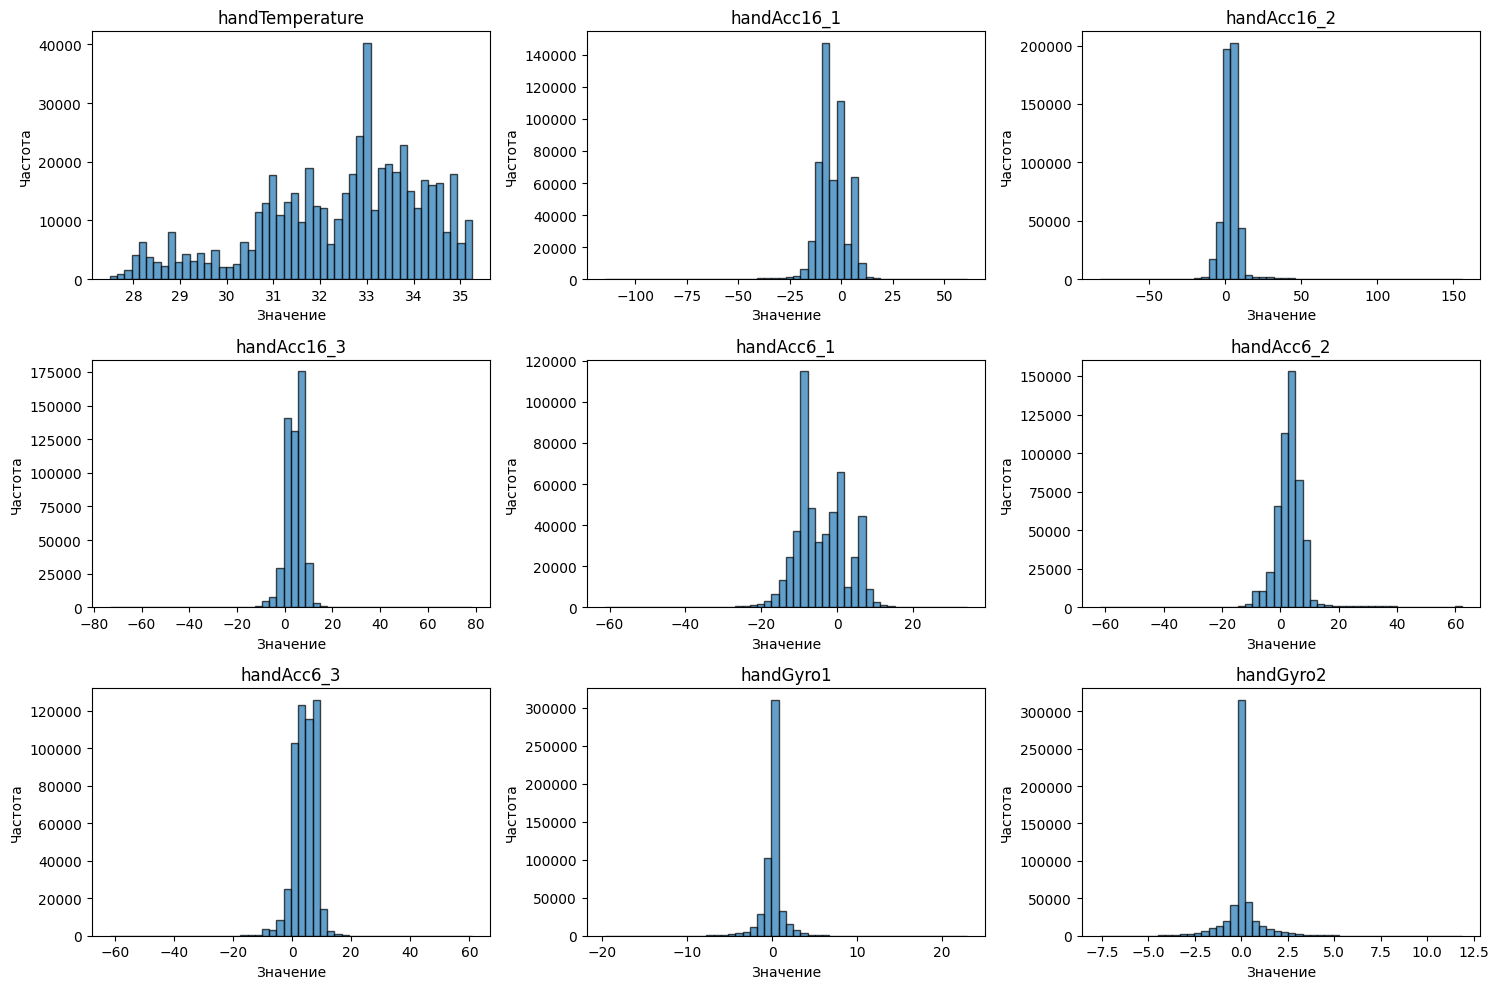

In [6]:
first_features = X.columns[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(first_features):
    axes[i].hist(X[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

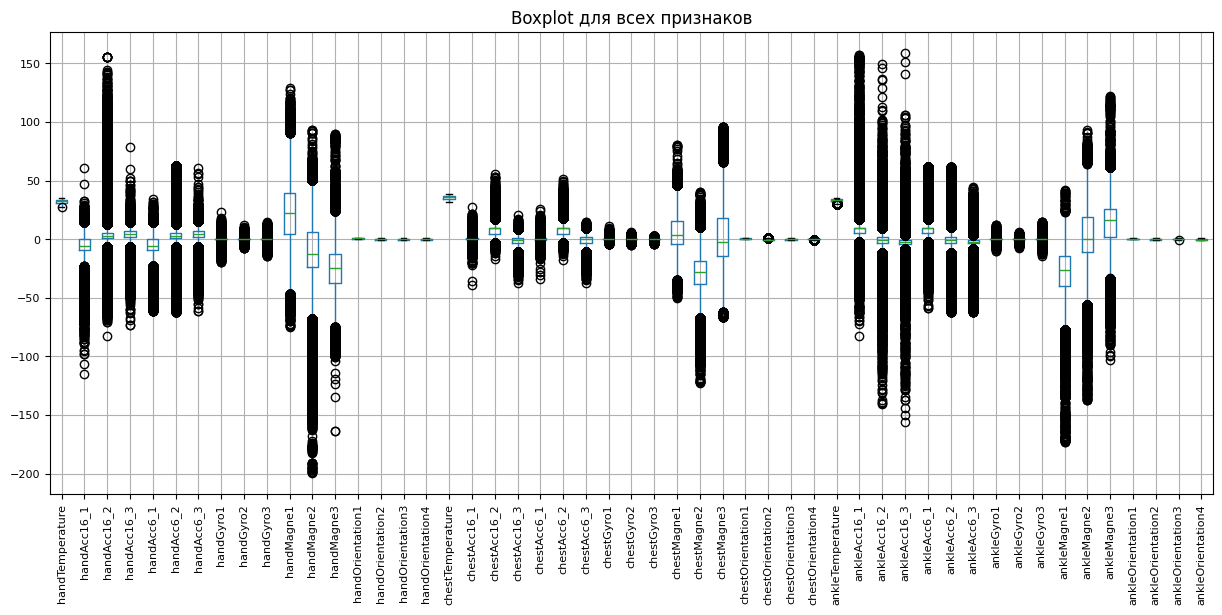

In [7]:
plt.figure(figsize=(15, 6))
X.boxplot(rot=90, fontsize=8)
plt.title('Boxplot для всех признаков')
plt.show()

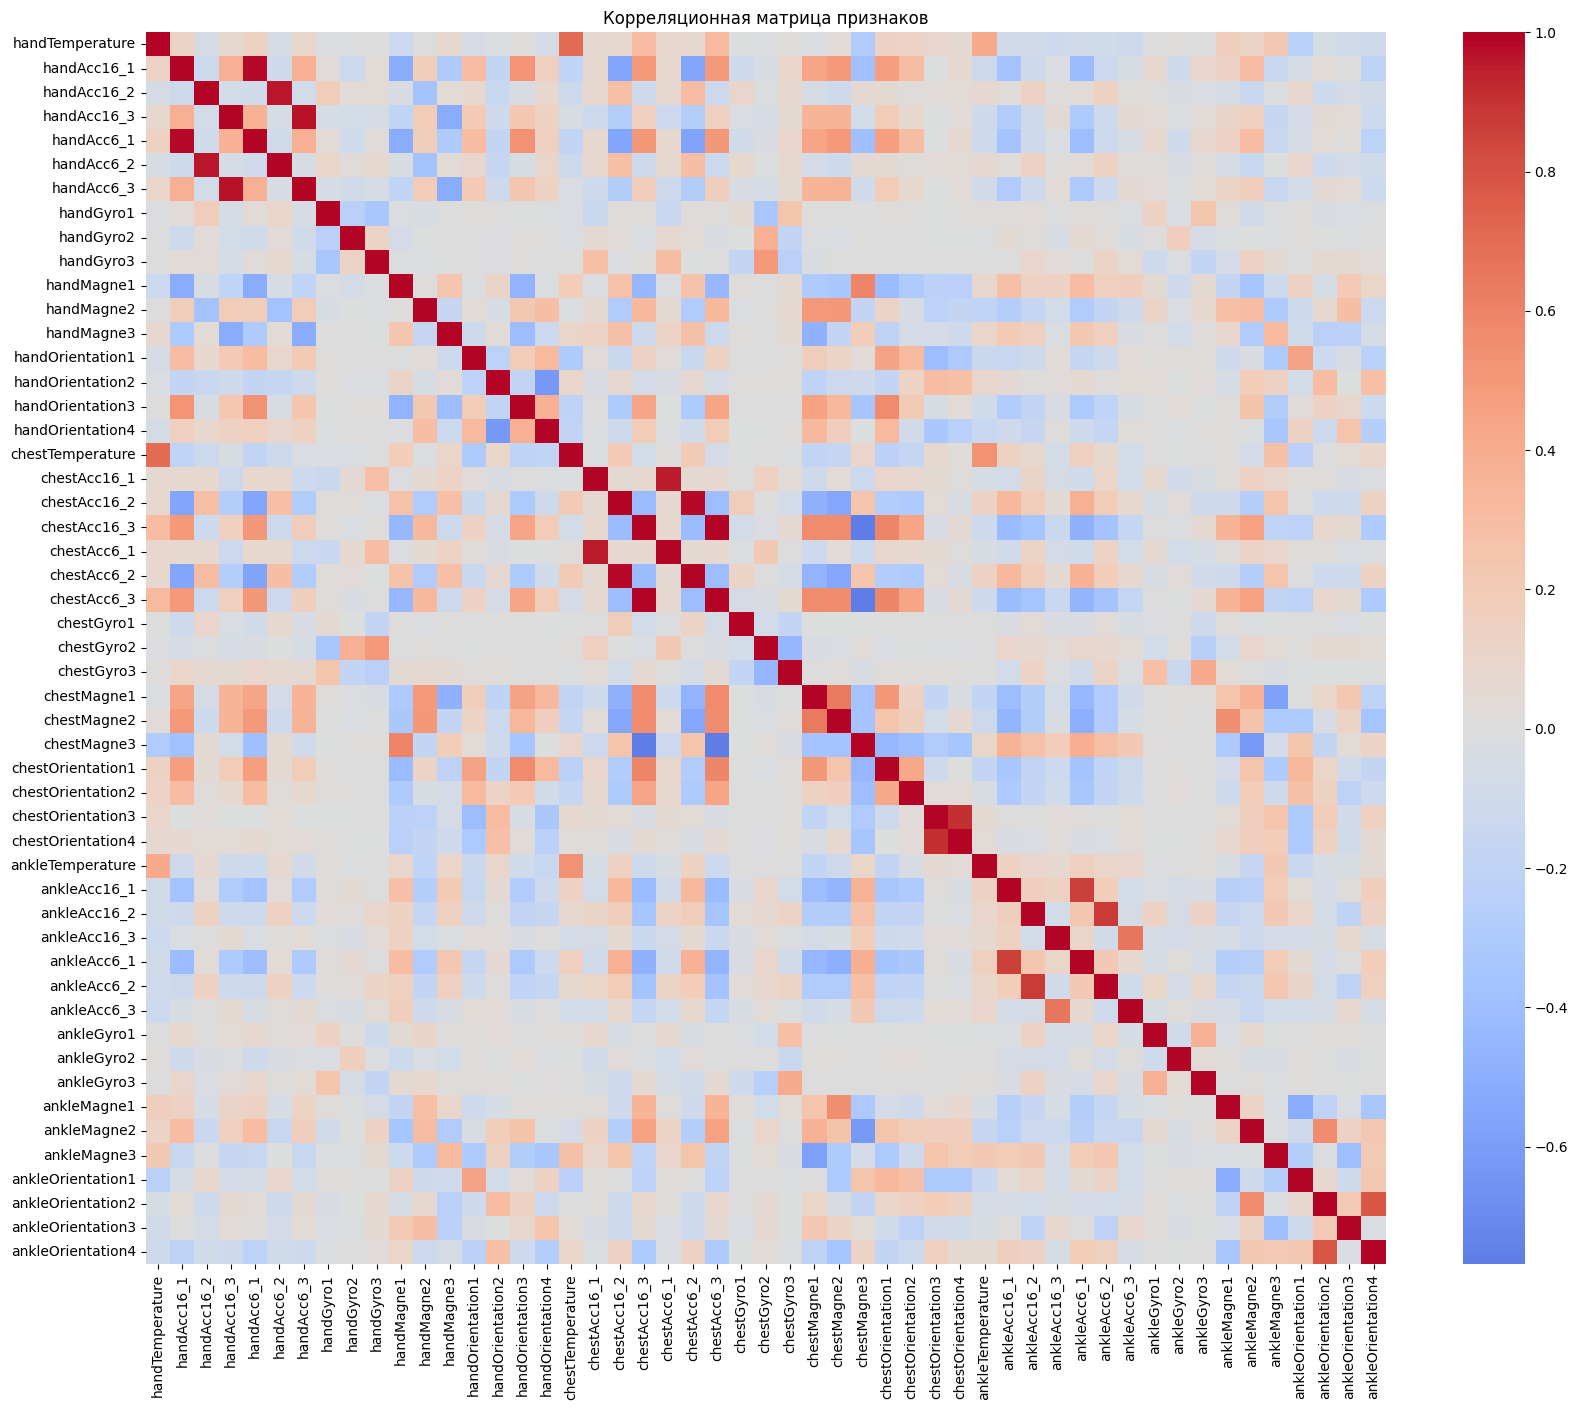

Пар с |corr| > 0.95: 6
('handAcc16_1', 'handAcc6_1', np.float64(0.9814368625706114))
('handAcc16_2', 'handAcc6_2', np.float64(0.9639352727481061))
('handAcc16_3', 'handAcc6_3', np.float64(0.9720894050514509))
('chestAcc16_1', 'chestAcc6_1', np.float64(0.9562254976195323))
('chestAcc16_2', 'chestAcc6_2', np.float64(0.9848524069364692))
('chestAcc16_3', 'chestAcc6_3', np.float64(0.9911125008128839))


In [8]:
# Вычисляем корреляцию Пирсона
corr_matrix = X.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Корреляционная матрица признаков')
plt.show()

# Находим пары признаков с корреляцией >0.95 или <-0.95
threshold = 0.95
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
print(f"Пар с |corr| > {threshold}: {len(high_corr_pairs)}")
for pair in high_corr_pairs[:10]:  # выведем первые 10
    print(pair)

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Среднее каждого признака после масштабирования:", X_scaled.mean(axis=0)[:5])
print("Стандартное отклонение:", X_scaled.std(axis=0)[:5])

Среднее каждого признака после масштабирования: [-1.81074963e-16 -6.89809383e-17  1.18560988e-17  6.45079556e-17
 -2.16643259e-17]
Стандартное отклонение: [1. 1. 1. 1. 1.]


In [10]:
# Удаляем признаки handAcc6_* и chestAcc6_* (оставляем handAcc16_* и chestAcc16_*)
cols_to_drop = ['handAcc6_1', 'handAcc6_2', 'handAcc6_3',
                'chestAcc6_1', 'chestAcc6_2', 'chestAcc6_3']
X_reduced = X.drop(columns=cols_to_drop)
print(f"Новое количество признаков: {X_reduced.shape[1]}")

Новое количество признаков: 45


In [11]:

X_scaled_reduced = scaler.fit_transform(X_reduced)
print("Масштабирование выполнено. Форма:", X_scaled_reduced.shape)

Масштабирование выполнено. Форма: (527389, 45)


Обработка k=2...
  silhouette = 0.1709
Обработка k=3...
  silhouette = 0.1499
Обработка k=4...
  silhouette = 0.1661
Обработка k=5...
  silhouette = 0.0942
Обработка k=6...
  silhouette = 0.1429
Обработка k=7...
  silhouette = 0.1620
Обработка k=8...
  silhouette = 0.1201
Обработка k=9...
  silhouette = 0.1391
Обработка k=10...
  silhouette = 0.1553


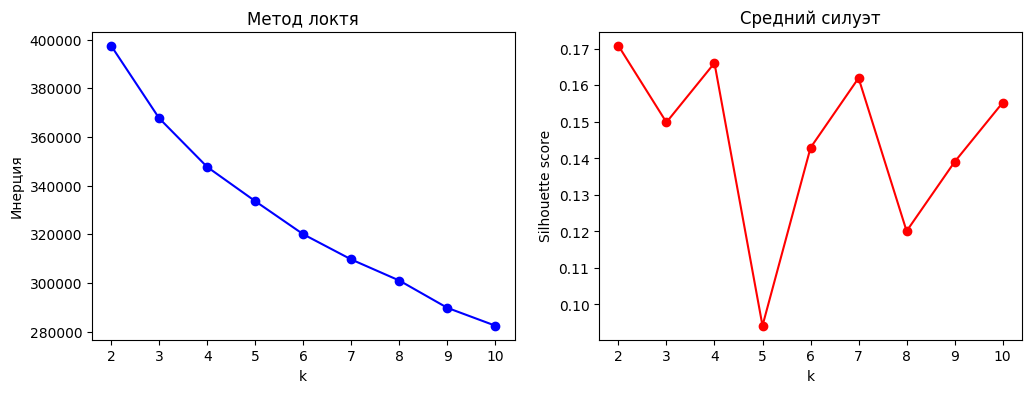

Лучшее k по силуэту: 2 (score = 0.1709)


In [12]:
sample_size = 10000
np.random.seed(42)
indices = np.random.choice(X_scaled_reduced.shape[0], sample_size, replace=False)
X_sample = X_scaled_reduced[indices]

inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    print(f"Обработка k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_sample)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_sample, kmeans.labels_)
    silhouettes.append(sil)
    print(f"  silhouette = {sil:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('k')
ax1.set_ylabel('Инерция')
ax1.set_title('Метод локтя')

ax2.plot(k_range, silhouettes, 'ro-')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Средний силуэт')
plt.show()

best_k = k_range[np.argmax(silhouettes)]
print(f"Лучшее k по силуэту: {best_k} (score = {max(silhouettes):.4f})")

In [ ]:
print("Размер выборки:", X_sample.shape)

Размер выборки: (50000, 45)


In [15]:
#  KMeans с k=8
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_sample)
kmeans_sil = silhouette_score(X_sample, kmeans_labels)
print(f"KMeans (k=8) -> silhouette = {kmeans_sil:.4f}")

KMeans (k=8) -> silhouette = 0.1661


In [16]:
agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(X_sample)
agg_sil = silhouette_score(X_sample, agg_labels)
print(f"Agglomerative (k=4) silhouette = {agg_sil:.4f}")

Agglomerative (k=4) silhouette = 0.0840


In [ ]:
best_sil = -1
best_params = None
best_labels = None

eps_values = [0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0]
min_samples_values = [5, 10, 20, 50]

for eps in eps_values:
    for min_samp in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samp)
        labels = db.fit_predict(X_sample)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        # Ищем от 2 до 6 кластеров
        if n_clusters < 2 or n_clusters > 6:
            continue
        mask = labels != -1
        if mask.sum() > n_clusters:
            sil = silhouette_score(X_sample[mask], labels[mask])
            if sil > best_sil:
                best_sil = sil
                best_params = (eps, min_samp)
                best_labels = labels
                print(f"eps={eps}, min_samples={min_samp} -> clusters={n_clusters}, silhouette={sil:.4f}")

if best_params:
    print(f"\nЛучший DBSCAN: eps={best_params[0]}, min_samples={best_params[1]}, silhouette={best_sil:.4f}")
else:
    print("Не найдено параметров, дающих 2-6 кластеров.")

Не найдено параметров, дающих 2-6 кластеров.


In [18]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_final.fit(X_scaled_reduced)
final_labels = kmeans_final.predict(X_scaled_reduced)

print("Распределение по кластерам:")
print(pd.Series(final_labels).value_counts().sort_index())

Распределение по кластерам:
0     59628
1    204008
2     88168
3    175585
Name: count, dtype: int64


Центроиды кластеров (средние значения признаков):
           handTemperature  handAcc16_1  handAcc16_2  handAcc16_3  handGyro1  \
Кластер 0            32.04        -4.38         7.14         3.09       0.08   
Кластер 1            32.15        -5.87         3.33         3.95      -0.03   
Кластер 2            32.76         4.46         1.98         7.04      -0.00   
Кластер 3            32.79        -7.21         2.45         3.10      -0.01   

           handGyro2  handGyro3  handMagne1  handMagne2  handMagne3  ...  \
Кластер 0       0.11       0.04       18.14      -31.23      -24.07  ...   
Кластер 1       0.02      -0.01       29.38       -7.11      -21.36  ...   
Кластер 2       0.00      -0.02       -3.12        9.81      -38.10  ...   
Кластер 3       0.02       0.01       22.38      -17.14      -21.76  ...   

           ankleGyro1  ankleGyro2  ankleGyro3  ankleMagne1  ankleMagne2  \
Кластер 0        0.01        0.02       -0.05       -59.16        -7.60   
Кластер 1        0

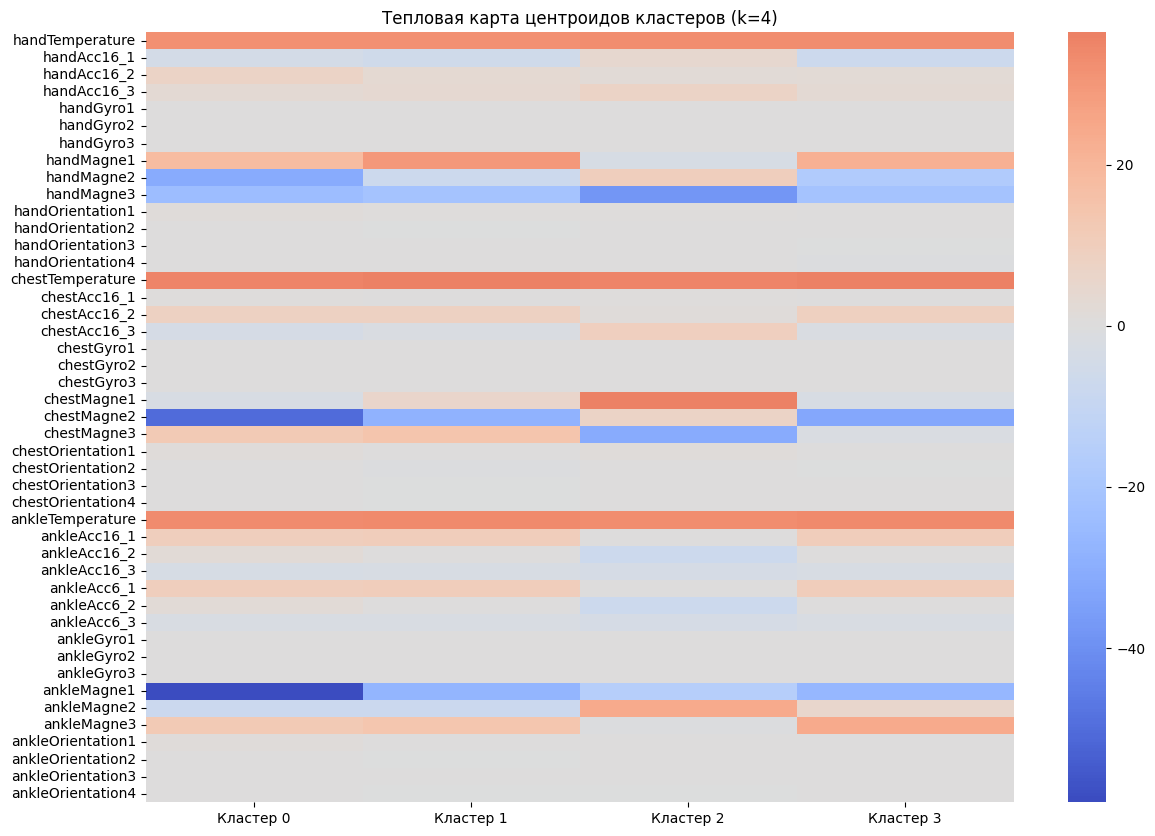

Топ-10 признаков, которые сильнее всего отличают кластеры:
chestMagne2     581.119984
chestMagne3     436.459362
ankleMagne1     351.535161
chestMagne1     338.368815
handMagne2      298.175734
ankleMagne2     225.847762
handMagne1      195.973955
ankleMagne3     105.602815
handMagne3       63.064985
chestAcc16_3     33.574394
dtype: float64


In [19]:
# Получаем центроиды в исходных единицах измерения
centroids_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
centroid_df = pd.DataFrame(centroids_original, columns=X_reduced.columns)
centroid_df.index = [f'Кластер {i}' for i in range(4)]

print("Центроиды кластеров (средние значения признаков):")
print(centroid_df.round(2))

plt.figure(figsize=(14, 10))
sns.heatmap(centroid_df.T, cmap='coolwarm', center=0)
plt.title('Тепловая карта центроидов кластеров (k=4)')
plt.show()

# Признаки с наибольшей разницей между кластерами
feature_variance = centroid_df.var(axis=0).sort_values(ascending=False)
print("Топ-10 признаков, которые сильнее всего отличают кластеры:")
print(feature_variance.head(10))

Исходя из анализа центроидов, кластер 2 отличается наиболее высокими ускорениями на руке и повышенной температурой, что позволяет интерпретировать его как активный тип активности (бег, прыжки).
Кластер 1 — самый многочисленный — имеет умеренные значения всех сенсоров, что характерно для состояния покоя или малой активности (сидение, сон).
Кластеры 0 и 3 занимают промежуточное положение, возможно, соответствуя ходьбе и циклическим движениям (велосипед).